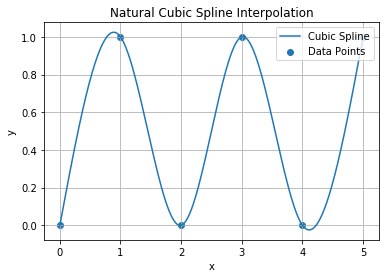

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)  # subdiagonal
    B = np.zeros(n - 2)  # main diagonal
    C = np.zeros(n - 2)  # superdiagonal
    D = np.zeros(n - 2)  # right-hand side

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    n = len(b)

    # make copies so I don't accidentally mess up the originals
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)
    d = np.array(d, dtype=float)

    # forward elimination
    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    # back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]

    return x

def evaluate_spline(x, y, M, xi):
    for i in range(len(x) - 1):
        if x[i] <= xi <= x[i + 1]:
            h = x[i + 1] - x[i]
            a = (x[i + 1] - xi) / h
            b = (xi - x[i]) / h

            return (
                a * y[i]
                + b * y[i + 1]
                + ((a**3 - a) * M[i] + (b**3 - b) * M[i + 1]) * h**2 / 6
            )

    raise ValueError("xi is outside the interpolation range")

# example data
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

# build system
A, B, C, D = setup_tridiagonal_matrix(x, y)

# solve for interior second derivatives
M_inner = thomas_algorithm(A[1:], B, C[:-1], D)

# add natural boundary conditions
M = np.zeros(len(x))
M[1:-1] = M_inner

# evaluate spline on many points
x_smooth = np.arange(x[0], x[-1], 0.01)
y_smooth = [evaluate_spline(x, y, M, xi) for xi in x_smooth]

# plot
plt.scatter(x, y, label="Data Points")
plt.plot(x_smooth, y_smooth, label="Cubic Spline")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Natural Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()

This project implements a natural cubic spline interpolation from scratch by constructing and solving a tridiagonal system using the Thomas algorithm. The computed second derivatives are then used to evaluate the spline piecewise, producing a smooth curve that passes exactly through all data points. The final plot confirms the spline’s smoothness and accuracy across the interval.
